---

# CUSTOM AXIS TICKS

---

>---
>You can apply **custom x-ticks** with the `set_xticks()` and `xticks()` functions
>
>- `ax.set_xticks(iterable)`
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

In [2]:
df = pd.read_csv('../Data/ca_housing.csv', 
                 parse_dates=['period_begin', 'period_end'])

df = (df
    .pivot_table(index='period_begin', 
                 columns='region_name', 
                 values='median_active_list_price', 
                 aggfunc='mean')
    .resample("QE").mean().round()
)

display(df.head(2), df.tail(2))
df.info()

region_name,Los Angeles,San Diego,San Francisco
period_begin,,,
2017-03-31,630557.0,637701.0,1263499.0
2017-06-30,650077.0,652195.0,1259083.0


region_name,Los Angeles,San Diego,San Francisco
period_begin,,,
2022-03-31,900615.0,885798.0,1293413.0
2022-06-30,906774.0,902425.0,1292479.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22 entries, 2017-03-31 to 2022-06-30
Freq: QE-DEC
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Los Angeles    22 non-null     float64
 1   San Diego      22 non-null     float64
 2   San Francisco  22 non-null     float64
dtypes: float64(3)
memory usage: 704.0 bytes


<br><br>

---


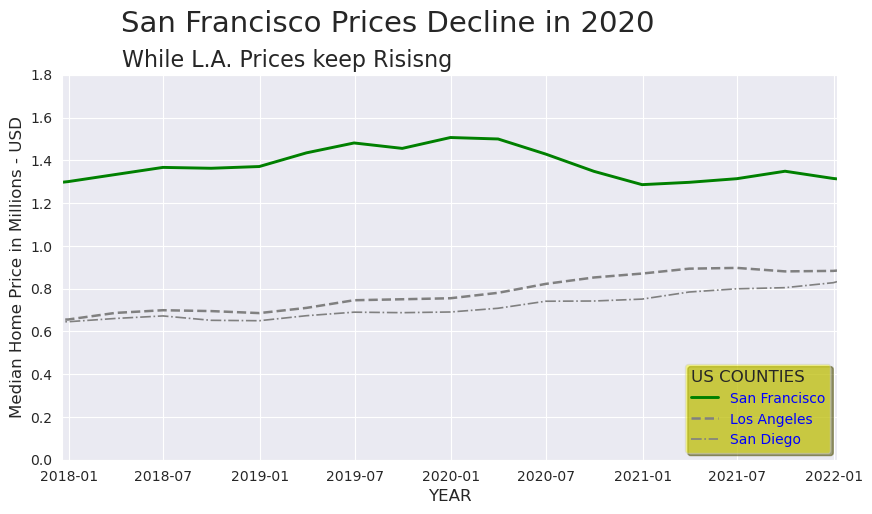

In [3]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()

ax.plot(df.index, df['San Francisco']/1e6, label='San Francisco',
        color='green', linestyle='-', linewidth=2.1)

ax.plot(df['Los Angeles']/1e6, label='Los Angeles', 
        color='gray', linestyle='--', linewidth=1.8)

ax.plot(df['San Diego']/1e6, label='San Diego',
        color='gray', linestyle='-.', linewidth=1.2)

fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21, x=0.45, y=1.01)
ax.set_title('While L.A. Prices keep Risisng', fontsize=16, x=0.29)
ax.set_xlabel('YEAR', fontsize=12)
ax.set_ylabel('Median Home Price in Millions - USD', fontsize=12)

ax.legend(loc='lower right', 
          title='US COUNTIES',
          title_fontsize='large',
          fontsize='medium',
          shadow=True,
          fancybox=True,
          framealpha=0.45,
          labelcolor='blue',
          facecolor='yellow',
          alignment='left')

ax.set_xlim(17520, 19000) # Manual calculation
ax.set_ylim(0, 1.8)
plt.show()

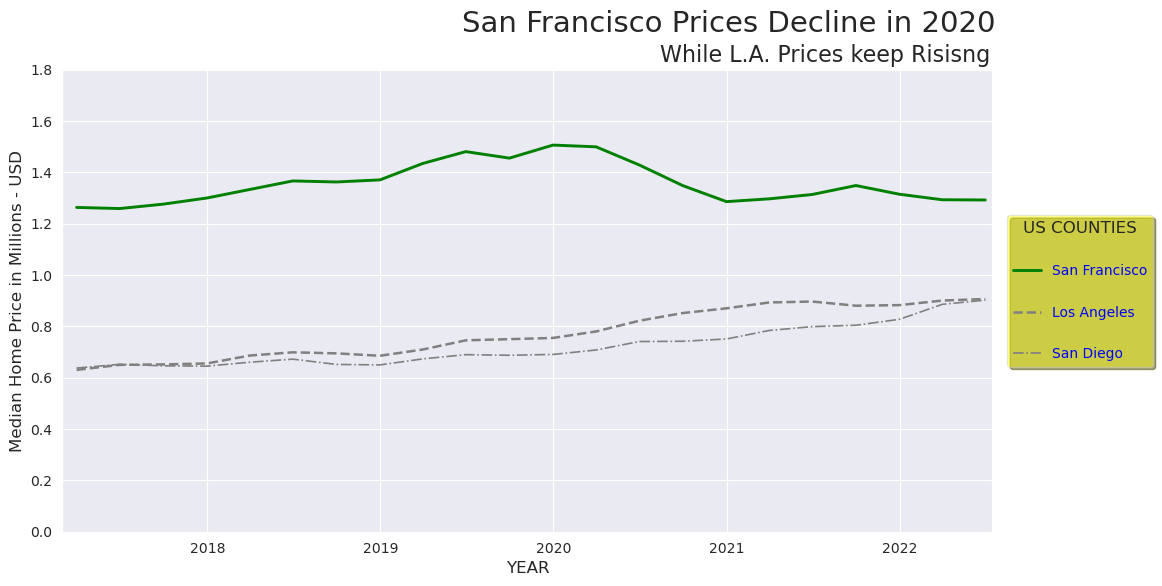

In [4]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot()

ax.plot(df.index, df['San Francisco'] / 1e6, label='San Francisco',
        color='green', linestyle='-', linewidth=2.1)

ax.plot(df['Los Angeles'] / 1e6, label='Los Angeles', 
        color='gray', linestyle='--', linewidth=1.8)

ax.plot(df['San Diego'] / 1e6, label='San Diego',
        color='gray', linestyle='-.', linewidth=1.2)

fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21, x=0.68)
ax.set_title('While L.A. Prices keep Risisng', fontsize=16, x=0.82)
ax.set_xlabel('YEAR', fontsize=12)
ax.set_ylabel('Median Home Price in Millions - USD', fontsize=12)

ax.legend(bbox_to_anchor=(1.18,0.7), 
          ncols=1,
          title='US COUNTIES',
          title_fontsize='large',
          fontsize='medium',
          shadow=True,
          fancybox=True,
          framealpha=0.45,
          labelcolor='blue',
          facecolor='yellow',
          labelspacing=2 # create space between each line of the legend
         )
# -------------------------------------------------------------------------
ax.set_xlim(pd.Timestamp('2017-03-01'), pd.Timestamp('2022-07-15')) # Better way (More data)
ax.set_ylim(0, 1.8)
plt.show()

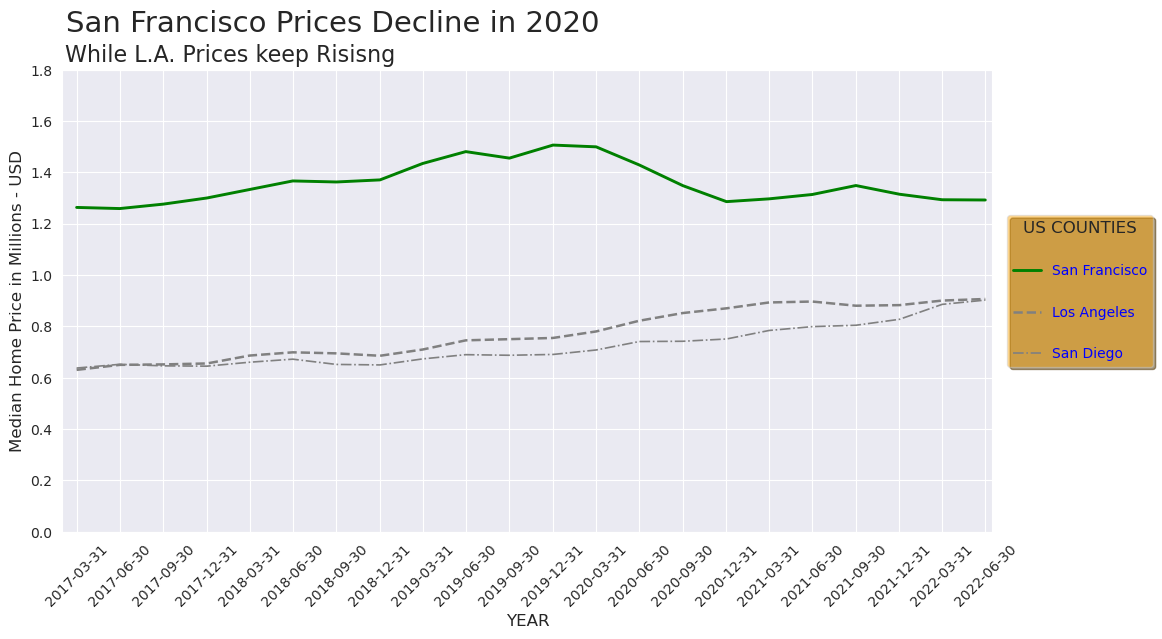

In [5]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot()

ax.plot(df.index, df['San Francisco'] / 1e6, label='San Francisco',
        color='green', linestyle='-', linewidth=2.1)

ax.plot(df['Los Angeles'] / 1e6, label='Los Angeles', 
        color='gray', linestyle='--', linewidth=1.8)

ax.plot(df['San Diego'] / 1e6, label='San Diego',
        color='gray', linestyle='-.', linewidth=1.2)

fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21, x=0.35)
ax.set_title('While L.A. Prices keep Risisng', fontsize=16, x=0.18)
ax.set_xlabel('YEAR', fontsize=12)
ax.set_ylabel('Median Home Price in Millions - USD', fontsize=12)

ax.legend(bbox_to_anchor=(1.18,0.7), 
          ncols=1,
          title='US COUNTIES',
          title_fontsize='large',
          fontsize='medium',
          shadow=True,
          fancybox=True,
          framealpha=0.45,
          labelcolor='blue',
          facecolor='orange',
          labelspacing=2 # create space between each line of the legend
         )
# -------------------------------------------------------------------------
ax.set_xlim(pd.Timestamp('2017-03-01'), pd.Timestamp('2022-07-15')) # Better way (More data)
ax.set_ylim(0, 1.8)

ax.set_xticks(df.index[:])
plt.xticks(rotation=45)
plt.show()

>---
>
>if the Plot above has too many ticks on the x-axis we can fix it by consider groups of 6 months rather than 3 months. Like in the upper plot
>
>---

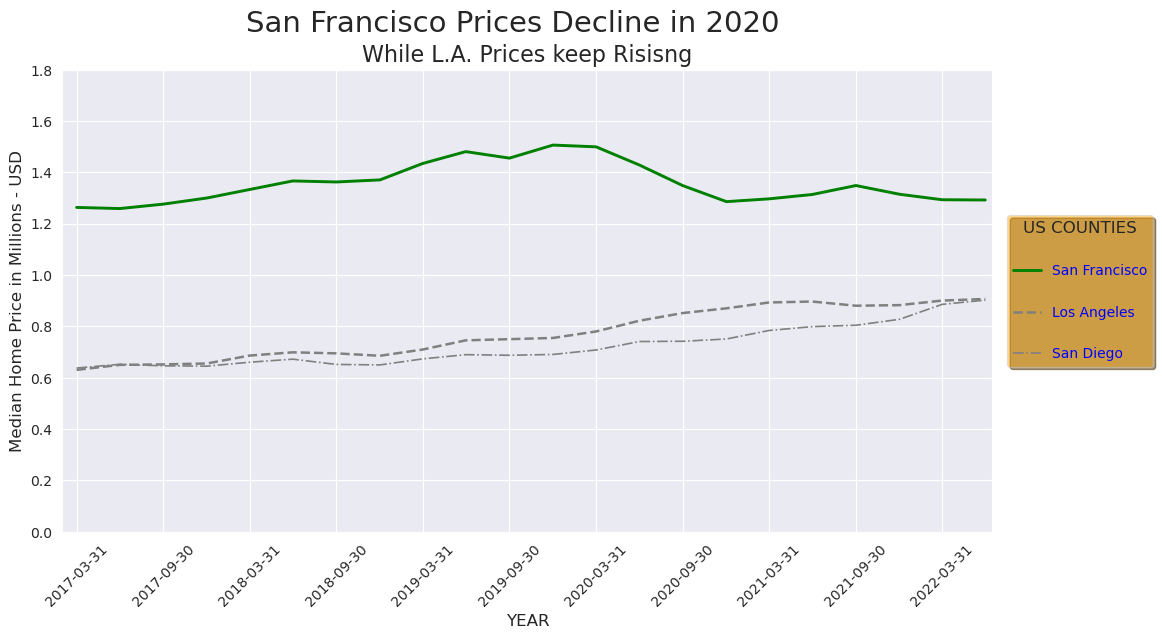

In [6]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot()

ax.plot(df.index, df['San Francisco'] / 1e6, label='San Francisco',
        color='green', linestyle='-', linewidth=2.1)

ax.plot(df['Los Angeles'] / 1e6, label='Los Angeles', 
        color='gray', linestyle='--', linewidth=1.8)

ax.plot(df['San Diego'] / 1e6, label='San Diego',
        color='gray', linestyle='-.', linewidth=1.2)

fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21)
ax.set_title('While L.A. Prices keep Risisng', fontsize=16)
ax.set_xlabel('YEAR', fontsize=12)
ax.set_ylabel('Median Home Price in Millions - USD', fontsize=12)

ax.legend(bbox_to_anchor=(1.18,0.7), 
          ncols=1,
          title='US COUNTIES',
          title_fontsize='large',
          fontsize='medium',
          shadow=True,
          fancybox=True,
          framealpha=0.45,
          labelcolor='blue',
          facecolor='orange',
          labelspacing=2 # create space between each line of the legend
         )
# -------------------------------------------------------------------------
ax.set_xlim(pd.Timestamp('2017-03-01'), pd.Timestamp('2022-07-15')) # Better way (More data)
ax.set_ylim(0, 1.8)

ax.set_xticks(df.index[::2]) # it help consider groups of 6 months
plt.xticks(rotation=45)
plt.show()

>---
>
>Finally if we are interested in showing only a couple of dates we can set the plot this way.
>
>---

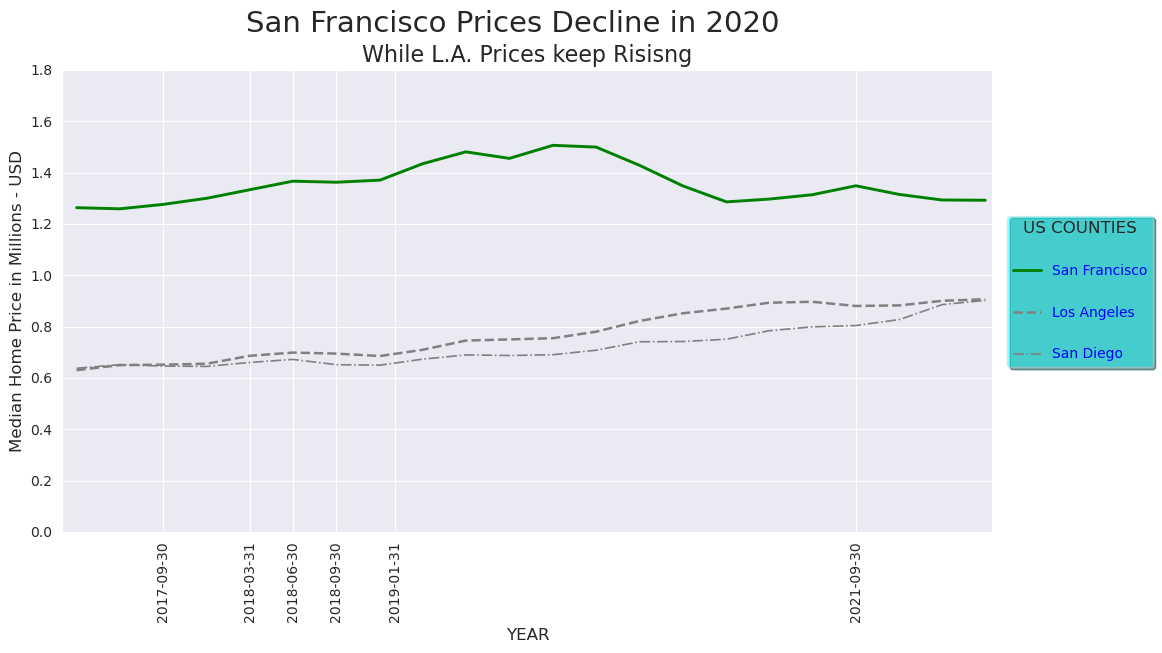

In [8]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot()

ax.plot(df.index, df['San Francisco'] / 1e6, label='San Francisco',
        color='green', linestyle='-', linewidth=2.1)

ax.plot(df['Los Angeles'] / 1e6, label='Los Angeles', 
        color='gray', linestyle='--', linewidth=1.8)

ax.plot(df['San Diego'] / 1e6, label='San Diego',
        color='gray', linestyle='-.', linewidth=1.2)

fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21)
ax.set_title('While L.A. Prices keep Risisng', fontsize=16)
ax.set_xlabel('YEAR', fontsize=12)
ax.set_ylabel('Median Home Price in Millions - USD', fontsize=12)

ax.legend(bbox_to_anchor=(1.18,0.7), 
          ncols=1,
          title='US COUNTIES',
          title_fontsize='large',
          fontsize='medium',
          shadow=True,
          fancybox=True,
          framealpha=0.45,
          labelcolor='blue',
          facecolor='cyan',
          labelspacing=2 # create space between each line of the legend
         )
# -------------------------------------------------------------------------
ax.set_xlim(pd.Timestamp('2017-03-01'), 
            pd.Timestamp('2022-07-15')) # Better way (More data)
ax.set_ylim(0, 1.8)

ax.set_xticks(['2017-09-30', '2018-03-31', 
               '2018-06-30', '2018-09-30', 
               '2019-01-31','2021-09-30']) # it help consider groups of 6 months
plt.xticks(rotation=90)
plt.show()

In [9]:
df

region_name,Los Angeles,San Diego,San Francisco
period_begin,,,
2017-03-31,630557.0,637701.0,1263499.0
2017-06-30,650077.0,652195.0,1259083.0
2017-09-30,651898.0,646279.0,1276378.0
2017-12-31,655576.0,645082.0,1300292.0
2018-03-31,686360.0,660420.0,1333339.0
2018-06-30,698958.0,672297.0,1366697.0
2018-09-30,694917.0,651794.0,1362654.0
2018-12-31,685525.0,649886.0,1370784.0
2019-03-31,709834.0,673348.0,1434700.0
